# Steinbeck, Akerlof e il mercato delle auto usate  
## Un notebook agent-based “pubblicabile” per Jupyter

Questo notebook costruisce un **modello agent-based (ABM)** per ragionare intorno al testo su *Steinbeck e i lemons*.

L'idea di fondo è distinguere fra:

1. **spiegazione Akerlof-standard**: eterogeneità qualitativa + asimmetria informativa;
2. **spiegazione Steinbeck-estesa**: oltre all'asimmetria, contano anche  
   - domanda **costretta**,
   - vulnerabilità socio-antropologica dei compratori,
   - potere locale / monopolistico dell'offerta,
   - opportunismo di one-shot transactions,
   - discriminazione di prezzo,
   - debolezza o assenza di istituzioni correttive.

Il notebook è pensato per essere:
- leggibile in **Jupyter**,
- facilmente pubblicabile via **Voilà / Binder / GitHub**,
- modificabile per esperimenti ulteriori.

## 1. Fondamento teorico

Nel testo di partenza si sostiene che la situazione **non può essere spiegata solo con un eccesso di domanda**: un eccesso di domanda può far salire temporaneamente i prezzi, ma non basta a spiegare **perché diventi conveniente vendere sistematicamente beni di bassa qualità**.  
La lettura canonica è quella di **Akerlof (1970)**: quando il venditore conosce la qualità del bene meglio del compratore, il prezzo tende a riflettere una qualità media attesa; i venditori dei beni migliori si ritirano, e sul mercato restano soprattutto i “lemons”.

Ma il caso Steinbeckiano aggiunge elementi ulteriori:

- i compratori sono **scarsamente informati** non solo sulla qualità del bene, ma anche sulle **regole pratiche del mercato**;
- la domanda è spesso **urgente, costretta, senza rinvio**;
- l'incontro tra domanda e offerta è spesso **unico**, quindi aumenta l'incentivo opportunistico;
- i venditori operano talvolta in condizioni di **potere locale**, quasi monopolistico o collusivo;
- il prezzo può essere **personalizzato** sfruttando vulnerabilità e urgenza;
- le istituzioni che potrebbero disciplinare il mercato possono essere **deboli o assenti**.

Perciò il modello qui sotto non è soltanto un Akerlof “tradotto in simulazione”, ma un piccolo laboratorio per distinguere:
- **fallimento informativo puro**,
- **fallimento informativo + potere di mercato + vulnerabilità sociale**,
- **correzione istituzionale parziale**.

## 2. Struttura del modello

Gli agenti sono due:

### Compratori
Ogni compratore ha:
- un budget,
- un grado di urgenza (*need*),
- un livello di alfabetizzazione di mercato (*market literacy*),
- una tolleranza al rischio,
- una vulnerabilità socio-antropologica sintetica.

### Venditori
Ogni venditore possiede:
- una o più auto,
- un mark-up di base,
- una propensione opportunistica,
- una capacità di discriminazione di prezzo.

### Auto
Ogni auto ha:
- qualità reale,
- costo del venditore,
- bandiera *good / lemon*.

### Istituzioni
Le istituzioni agiscono in modo ridotto ma utile:
- ispezioni casuali,
- standard minimi di qualità,
- riduzione della possibilità di sovrapprezzo,
- uscita dal mercato di alcune auto molto scadenti.

---

Il modello è deliberatamente **semplice e trasparente**, così da essere usato come notebook didattico, esplorativo e pubblicabile online.

In [1]:




import math
from pathlib import Path
import random
from dataclasses import dataclass, field
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown
    HAS_WIDGETS = True
except Exception:
    from IPython.display import Markdown
    HAS_WIDGETS = False

plt.rcParams["figure.figsize"] = (10, 5)
np.set_printoptions(suppress=True)


FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(exist_ok=True)

TABLES_DIR = Path("./tables")
TABLES_DIR.mkdir(exist_ok=True)


Per replicabilità

In [2]:
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)


## 3. Classi del modello

In [3]:


@dataclass
class Car:
    quality: float                # 0..1
    seller_cost: float
    is_good: bool

@dataclass
class Buyer:
    buyer_id: int
    budget: float
    need: float                   # 0..1
    market_literacy: float        # 0..1
    risk_tolerance: float         # 0..1
    vulnerability: float          # 0..1
    purchased: bool = False
    surplus: float = 0.0
    received_quality: Optional[float] = None
    paid_price: Optional[float] = None

    def perceived_quality(self, true_quality: float, info_asymmetry: float) -> float:
        # Più literacy -> meno rumore percettivo; più asimmetria -> più rumore
        sigma = max(0.02, info_asymmetry * (1.1 - self.market_literacy) * 0.35)
        noisy_signal = np.random.normal(loc=true_quality, scale=sigma)
        return float(np.clip(noisy_signal, 0.0, 1.0))

    def willingness_to_pay(self, expected_quality: float, forced_demand: float) -> float:
        # domanda costretta: l'urgenza aumenta la disponibilità a pagare
        urgency_multiplier = 1 + forced_demand * self.need * 0.8
        fragility_multiplier = 1 + 0.35 * self.vulnerability
        caution_discount = 1 - 0.25 * (1 - self.risk_tolerance)
        base_value = 40 + 160 * expected_quality
        return base_value * urgency_multiplier * fragility_multiplier * caution_discount

@dataclass
class Seller:
    seller_id: int
    base_markup: float
    opportunism: float            # 0..1
    price_discrimination: float   # 0..1
    inventory: List[Car] = field(default_factory=list)

    def quote_price(
        self,
        car: Car,
        buyer: Buyer,
        local_market_power: float,
        institution_strength: float
    ) -> float:
        # markup di base
        markup = self.base_markup

        # potere di mercato locale
        markup += local_market_power * (0.25 + 0.45 * self.opportunism)

        # discriminazione di prezzo su bisogno + vulnerabilità
        discrim = self.price_discrimination * (0.6 * buyer.need + 0.6 * buyer.vulnerability)

        # le istituzioni erodono il sovrapprezzo opportunistico
        governance_discount = 1 - 0.55 * institution_strength

        # i lemons sono spesso particolarmente profittevoli se il venditore è opportunista
        lemon_push = 1 + (0.25 * self.opportunism if not car.is_good else 0.0)

        price = car.seller_cost * (1 + markup + discrim) * lemon_push * governance_discount
        return max(price, car.seller_cost * 1.02)


## 4. Ambiente di simulazione

In [4]:


class SteinbeckLemonsABM:
    def __init__(
        self,
        n_buyers: int = 200,
        n_sellers: int = 25,
        cars_per_seller: int = 8,
        share_good_cars: float = 0.35,
        info_asymmetry: float = 0.55,
        forced_demand: float = 0.60,
        local_market_power: float = 0.55,
        price_discrimination: float = 0.60,
        institution_strength: float = 0.15,
        inspection_probability: float = 0.10,
        min_quality_standard: float = 0.18,
        seed: int = 42
    ):
        self.n_buyers = n_buyers
        self.n_sellers = n_sellers
        self.cars_per_seller = cars_per_seller
        self.share_good_cars = share_good_cars
        self.info_asymmetry = info_asymmetry
        self.forced_demand = forced_demand
        self.local_market_power = local_market_power
        self.price_discrimination = price_discrimination
        self.institution_strength = institution_strength
        self.inspection_probability = inspection_probability
        self.min_quality_standard = min_quality_standard
        self.seed = seed

        random.seed(seed)
        np.random.seed(seed)

        self.buyers: List[Buyer] = []
        self.sellers: List[Seller] = []
        self.history: List[Dict] = []

        self._setup_agents()

    def _draw_car(self, good: bool) -> Car:
        if good:
            quality = float(np.clip(np.random.normal(0.78, 0.08), 0.45, 1.0))
            cost = 70 + 120 * quality + np.random.uniform(5, 20)
        else:
            quality = float(np.clip(np.random.normal(0.28, 0.10), 0.02, 0.58))
            cost = 18 + 65 * quality + np.random.uniform(0, 12)
        return Car(quality=quality, seller_cost=float(cost), is_good=good)

    def _setup_agents(self):
        self.buyers = []
        self.sellers = []

        for i in range(self.n_buyers):
            self.buyers.append(
                Buyer(
                    buyer_id=i,
                    budget=float(np.random.uniform(70, 230)),
                    need=float(np.random.beta(2.5, 1.8)),
                    market_literacy=float(np.random.beta(2.0, 2.5)),
                    risk_tolerance=float(np.random.beta(2.2, 2.2)),
                    vulnerability=float(np.random.beta(2.2, 2.0))
                )
            )

        for j in range(self.n_sellers):
            inv = []
            for _ in range(self.cars_per_seller):
                good = np.random.rand() < self.share_good_cars
                inv.append(self._draw_car(good))
            self.sellers.append(
                Seller(
                    seller_id=j,
                    base_markup=float(np.random.uniform(0.08, 0.25)),
                    opportunism=float(np.random.beta(2.0, 1.8)),
                    price_discrimination=self.price_discrimination,
                    inventory=inv
                )
            )

    def _apply_institutions_to_inventory(self):
        """
        Ispeziona una volta per periodo le auto ancora in inventario.
        Se un'auto è ispezionata e non supera lo standard minimo,
        viene rimossa prima che il mercato apra nel periodo.
        """
        inspected_count = 0
        blocked_count = 0

        if self.institution_strength <= 0 or self.inspection_probability <= 0:
            return inspected_count, blocked_count

        effective_inspection_prob = min(
            1.0,
            self.inspection_probability * (0.20 + 0.80 * self.institution_strength)
        )

        for seller in self.sellers:
            new_inventory = []
            for car in seller.inventory:
                inspected = np.random.rand() < effective_inspection_prob
                if inspected:
                    inspected_count += 1
                    if car.quality < self.min_quality_standard:
                        blocked_count += 1
                        continue
                new_inventory.append(car)
            seller.inventory = new_inventory

        return inspected_count, blocked_count

    def step(self, t: int):
        inspected_count, blocked_count = self._apply_institutions_to_inventory()
        available_sellers = [s for s in self.sellers if len(s.inventory) > 0]
        np.random.shuffle(self.buyers)

        trades = 0
        lemons_sold = 0
        good_sold = 0
        total_price = 0.0
        total_quality = 0.0
        failed_due_budget = 0
        failed_due_expectations = 0

        for buyer in self.buyers:
            if buyer.purchased:
                continue

            sellers_with_stock = [s for s in available_sellers if len(s.inventory) > 0]
            if not sellers_with_stock:
                break

            # incontro one-shot: il buyer osserva pochi venditori, non tutto il mercato
            sample_size = max(1, int(round(1 + (1 - self.local_market_power) * 4)))
            encountered = list(np.random.choice(sellers_with_stock, size=min(sample_size, len(sellers_with_stock)), replace=False))

            best_option = None
            best_surplus = -10**9

            for seller in encountered:
                for idx, car in enumerate(seller.inventory):
                    perceived_q = buyer.perceived_quality(car.quality, self.info_asymmetry)
                    wtp = buyer.willingness_to_pay(perceived_q, self.forced_demand)
                    quoted = seller.quote_price(
                        car=car,
                        buyer=buyer,
                        local_market_power=self.local_market_power,
                        institution_strength=self.institution_strength
                    )

                    # La domanda costretta riduce la soglia di accettazione del surplus
                    min_surplus_needed = -8 * self.forced_demand * buyer.need
                    surplus = wtp - quoted

                    if quoted <= buyer.budget and surplus > best_surplus and surplus >= min_surplus_needed:
                        best_surplus = surplus
                        best_option = (seller, idx, car, quoted, perceived_q)

            if best_option is None:
                # distinguiamo in modo grezzo due motivi di fallimento
                if buyer.budget < 70:
                    failed_due_budget += 1
                else:
                    failed_due_expectations += 1
                continue

            seller, idx, car, quoted, perceived_q = best_option
            sold_car = seller.inventory.pop(idx)

            buyer.purchased = True
            buyer.received_quality = sold_car.quality
            buyer.paid_price = quoted
            buyer.surplus = buyer.willingness_to_pay(sold_car.quality, self.forced_demand) - quoted

            trades += 1
            lemons_sold += int(not sold_car.is_good)
            good_sold += int(sold_car.is_good)
            total_price += quoted
            total_quality += sold_car.quality

        record = {
            "period": t,
            "trades": trades,
            "lemons_sold": lemons_sold,
            "good_cars_sold": good_sold,
            "share_lemons": (lemons_sold / trades) if trades else 0.0,
            "avg_price": (total_price / trades) if trades else 0.0,
            "avg_quality": (total_quality / trades) if trades else 0.0,
            "failed_due_budget": failed_due_budget,
            "failed_due_expectations": failed_due_expectations,
            "inspected_cars": inspected_count,
            "blocked_sales": blocked_count,
            "buyers_completed": sum(int(b.purchased) for b in self.buyers),
            "stock_left": sum(len(s.inventory) for s in self.sellers),
            "active_buyers_left": sum(int(not b.purchased) for b in self.buyers),
            "market_inactive": int(trades == 0)
        }
        self.history.append(record)

    def run(self, periods: int = 12) -> pd.DataFrame:
        for t in range(periods):
            stock_left = sum(len(s.inventory) for s in self.sellers)
            active_buyers = sum(int(not b.purchased) for b in self.buyers)
            if stock_left == 0 or active_buyers == 0:
                break
            self.step(t)
        return pd.DataFrame(self.history)

    def buyer_outcomes(self) -> pd.DataFrame:
        rows = []
        for b in self.buyers:
            rows.append({
                "buyer_id": b.buyer_id,
                "purchased": b.purchased,
                "budget": b.budget,
                "need": b.need,
                "market_literacy": b.market_literacy,
                "risk_tolerance": b.risk_tolerance,
                "vulnerability": b.vulnerability,
                "received_quality": b.received_quality,
                "paid_price": b.paid_price,
                "surplus": b.surplus
            })
        return pd.DataFrame(rows)


## 5. Funzioni di supporto per scenari e grafici

In [5]:

def aggregate_history(hist: pd.DataFrame) -> Dict[str, float]:
    total_trades = float(hist["trades"].sum())
    total_lemons = float(hist["lemons_sold"].sum())
    total_good = float(hist["good_cars_sold"].sum())
    total_inspected = float(hist["inspected_cars"].sum()) if "inspected_cars" in hist.columns else 0.0
    total_blocked = float(hist["blocked_sales"].sum()) if "blocked_sales" in hist.columns else 0.0

    if total_trades > 0:
        avg_price = float((hist["avg_price"] * hist["trades"]).sum() / total_trades)
        avg_quality = float((hist["avg_quality"] * hist["trades"]).sum() / total_trades)
        share_lemons = float(total_lemons / total_trades)
    else:
        avg_price = 0.0
        avg_quality = 0.0
        share_lemons = 0.0

    return {
        "total_trades": total_trades,
        "total_lemons": total_lemons,
        "total_good_cars": total_good,
        "share_lemons": share_lemons,
        "avg_price": avg_price,
        "avg_quality": avg_quality,
        "inspected_cars": total_inspected,
        "blocked_sales": total_blocked,
        "inspection_rate_per_trade": (total_inspected / total_trades) if total_trades else 0.0,
        "blocked_per_trade": (total_blocked / total_trades) if total_trades else 0.0,
    }

def run_scenario(name: str, periods: int = 12, seed: int = 42, **kwargs):
    model = SteinbeckLemonsABM(seed=seed, **kwargs)
    hist = model.run(periods=periods).copy()
    hist["scenario"] = name
    buyers = model.buyer_outcomes().copy()
    buyers["scenario"] = name
    return hist, buyers

def summarize_buyers(df_buyers: pd.DataFrame) -> pd.DataFrame:
    purchased = df_buyers[df_buyers["purchased"]]
    return pd.DataFrame([{
        "purchase_rate": df_buyers["purchased"].mean(),
        "avg_paid_price": purchased["paid_price"].mean() if len(purchased) else 0.0,
        "avg_received_quality": purchased["received_quality"].mean() if len(purchased) else 0.0,
        "avg_surplus_buyers": purchased["surplus"].mean() if len(purchased) else 0.0,
        "avg_surplus_all": df_buyers["surplus"].mean()
    }])

def save_current_figure(stem: str, dpi: int = 300):
    pdf_path = FIGURES_DIR / f"{stem}.pdf"
    png_path = FIGURES_DIR / f"{stem}.png"
    plt.tight_layout()
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=dpi, bbox_inches="tight")
    print(f"Salvata figura: {pdf_path} e {png_path}")

def plot_histories(df: pd.DataFrame, title_prefix: str = "", save: bool = True):
    metrics = ["trades", "share_lemons", "avg_price", "avg_quality"]
    filename_map = {
        "trades": "trades_over_time",
        "share_lemons": "lemons_share",
        "avg_price": "avg_price_over_time",
        "avg_quality": "quality_over_time",
    }
    for metric in metrics:
        fig, ax = plt.subplots()
        for scenario, g in df.groupby("scenario"):
            ax.plot(g["period"], g[metric], marker="o", label=scenario)
        ax.set_xlabel("Periodo")
        ax.set_ylabel(metric)
        ax.set_title(f"{title_prefix}{metric}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        if save:
            fig.tight_layout()
            fig.savefig(FIGURES_DIR / f"{filename_map[metric]}.pdf", bbox_inches="tight")
            fig.savefig(FIGURES_DIR / f"{filename_map[metric]}.png", dpi=300, bbox_inches="tight")
            print(f"Salvata figura: {FIGURES_DIR / (filename_map[metric] + '.pdf')}")
        plt.show()

def scenario_report(hist: pd.DataFrame, buyers: pd.DataFrame) -> pd.DataFrame:
    hist_sum = hist.groupby("scenario").apply(
        lambda x: pd.Series(aggregate_history(x)),
        include_groups=False
    ).reset_index()

    buyer_sum = buyers.groupby("scenario").apply(
        lambda x: pd.Series({
            "purchase_rate": x["purchased"].mean(),
            "avg_paid_price": x.loc[x["purchased"], "paid_price"].mean() if x["purchased"].any() else 0.0,
            "avg_received_quality": x.loc[x["purchased"], "received_quality"].mean() if x["purchased"].any() else 0.0,
            "avg_surplus_buyers": x.loc[x["purchased"], "surplus"].mean() if x["purchased"].any() else 0.0,
            "avg_surplus_all": x["surplus"].mean()
        }),
        include_groups=False
    ).reset_index()

    last_state = hist.groupby("scenario").tail(1)[
        ["scenario", "buyers_completed", "stock_left", "active_buyers_left", "market_inactive"]
    ].reset_index(drop=True)

    return hist_sum.merge(buyer_sum, on="scenario", how="left").merge(last_state, on="scenario", how="left")


## 6. Tre scenari teorici di base

Qui traduciamo direttamente l'argomento teorico in tre mondi possibili.

### Scenario A — Solo Akerlof
- alta asimmetria informativa,
- bassa domanda costretta,
- basso potere locale,
- bassa discriminazione,
- istituzioni quasi assenti ma non centrali.

### Scenario B — Steinbeck esteso
- asimmetria informativa,
- domanda costretta forte,
- potere locale elevato,
- discriminazione di prezzo,
- vulnerabilità sfruttata.

### Scenario C — Correzione istituzionale
- stessa struttura del caso Steinbeck,
- ma con istituzioni più forti: standard minimi e ispezioni più efficaci.

In [6]:


scenario_A = dict(
    share_good_cars=0.40,
    info_asymmetry=0.68,
    forced_demand=0.20,
    local_market_power=0.15,
    price_discrimination=0.10,
    institution_strength=0.05,
    inspection_probability=0.05,
    min_quality_standard=0.10
)

scenario_B = dict(
    share_good_cars=0.35,
    info_asymmetry=0.60,
    forced_demand=0.85,
    local_market_power=0.75,
    price_discrimination=0.75,
    institution_strength=0.08,
    inspection_probability=0.08,
    min_quality_standard=0.12
)

scenario_C = dict(
    share_good_cars=0.35,
    info_asymmetry=0.55,
    forced_demand=0.85,
    local_market_power=0.70,
    price_discrimination=0.55,
    institution_strength=0.75,
    inspection_probability=0.70,
    min_quality_standard=0.32
)

hA, bA = run_scenario("Solo Akerlof", periods=12, seed=42, **scenario_A)
hB, bB = run_scenario("Steinbeck esteso", periods=12, seed=42, **scenario_B)
hC, bC = run_scenario("Con istituzioni", periods=12, seed=42, **scenario_C)

hist_all = pd.concat([hA, hB, hC], ignore_index=True)
buyers_all = pd.concat([bA, bB, bC], ignore_index=True)

report = scenario_report(hist_all, buyers_all)
report

paper_table = report[[
    "scenario",
    "total_trades",
    "share_lemons",
    "avg_price",
    "avg_quality",
    "purchase_rate",
    "avg_surplus_buyers",
    "blocked_sales"
]].copy().round(3)

paper_table.columns = [
    "Scenario",
    "Total trades",
    "Lemons share",
    "Average price",
    "Average quality",
    "Purchase rate",
    "Buyer surplus",
    "Blocked sales"
]

paper_table.to_latex(TABLES_DIR / "results_table.tex", index=False, float_format="%.3f")
print(f"Salvata tabella: {TABLES_DIR / 'results_table.tex'}")


Salvata tabella: tables/results_table.tex


**Nota tecnica.** In questa versione corretta:

- le metriche per-periodo valgono `0.0` quando in quel periodo non avviene alcuno scambio;
- la simulazione si interrompe automaticamente se il mercato è esaurito, cioè quando non ci sono più auto o non ci sono più compratori attivi;
- i riepiloghi dei compratori evitano medie su insiemi vuoti.

Così scompaiono i `NaN` spurii, mentre l'eventuale inattività del mercato resta leggibile nelle colonne `market_inactive`, `stock_left`, `active_buyers_left`.

## 7. Lettura sintetica dei risultati

Salvata figura: figures/trades_over_time.pdf


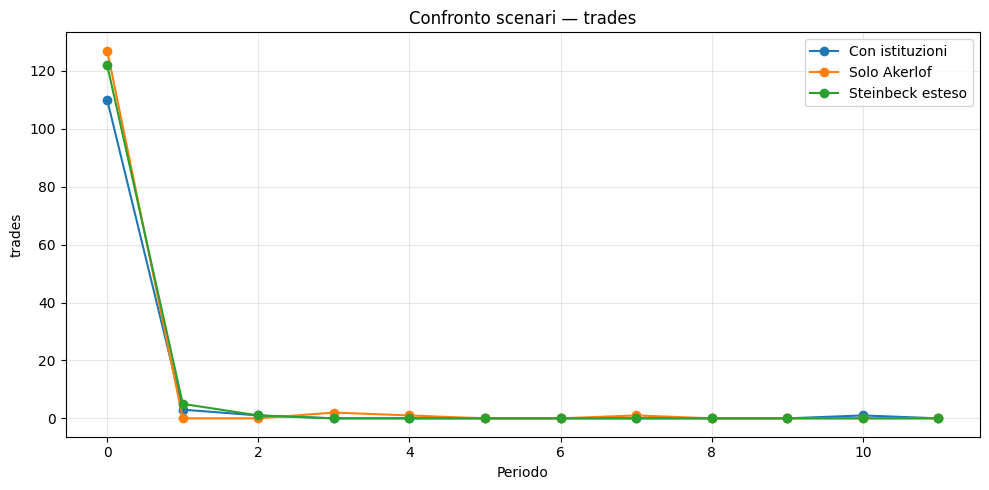

Salvata figura: figures/lemons_share.pdf


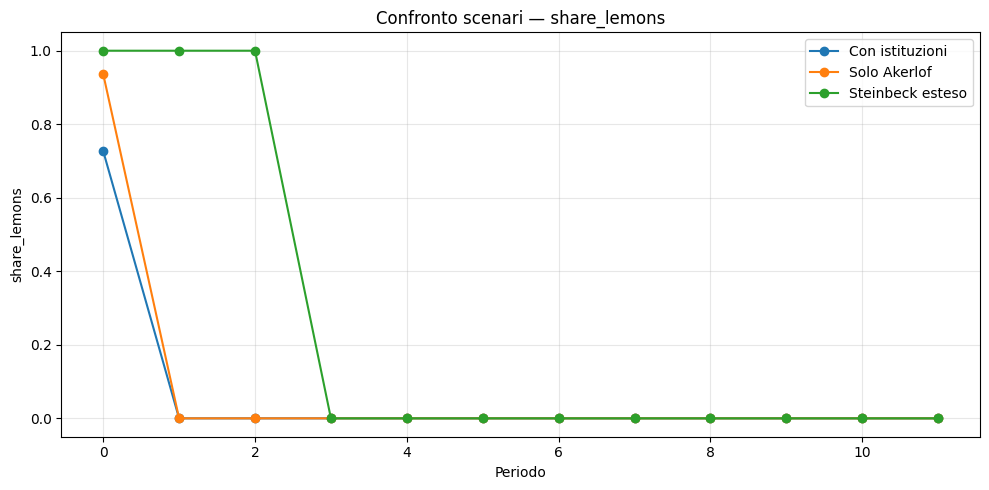

Salvata figura: figures/avg_price_over_time.pdf


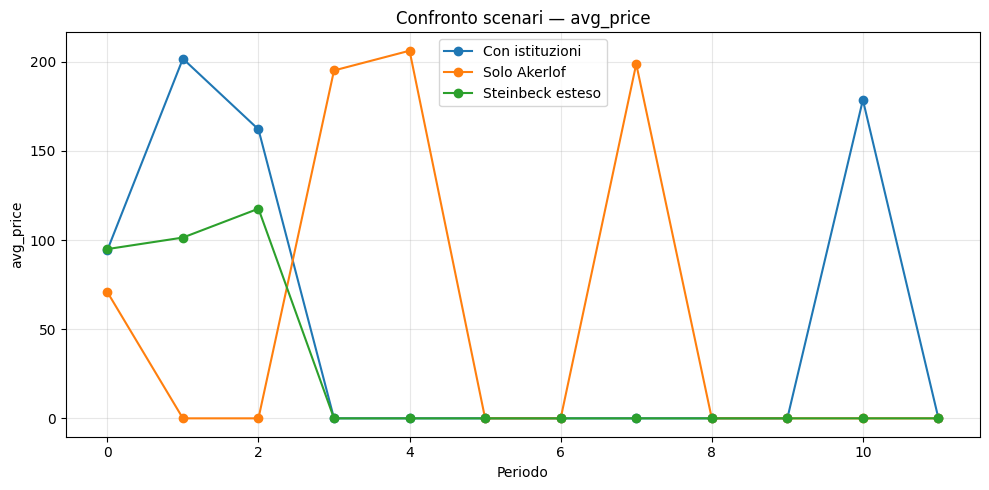

Salvata figura: figures/quality_over_time.pdf


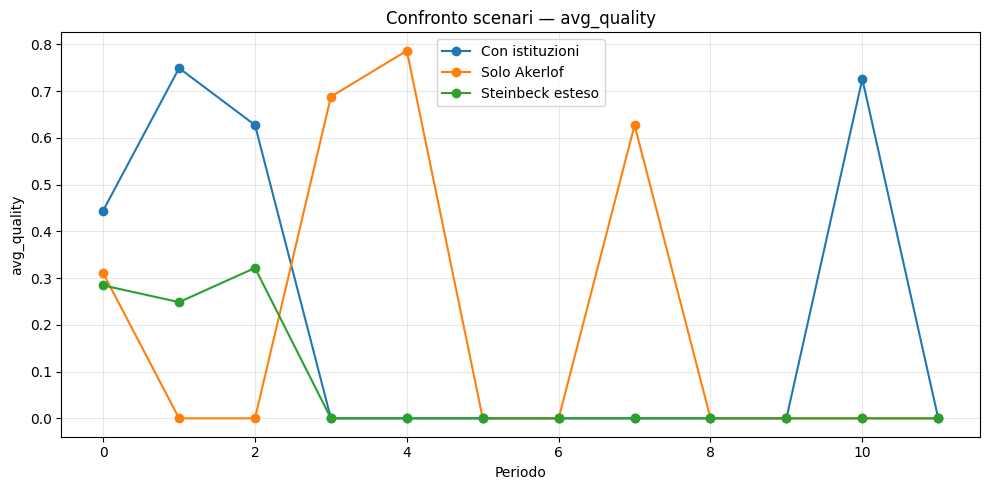

,scenario,total_trades,total_lemons,total_good_cars,share_lemons,avg_price,avg_quality,inspected_cars,blocked_sales,inspection_rate_per_trade,blocked_per_trade,purchase_rate,avg_paid_price,avg_received_quality,avg_surplus_buyers,avg_surplus_all,buyers_completed,stock_left,active_buyers_left,market_inactive
0,Con istituzioni,115.0,80.0,35.0,0.696,98.450,0.456,374.0,48.0,3.252,0.417,0.575,98.450,0.456,67.016,38.534,115,37,85,1
1,Solo Akerlof,131.0,119.0,12.0,0.908,74.714,0.322,12.0,0.0,0.092,0.000,0.655,74.714,0.322,28.881,18.917,131,69,69,1
2,Steinbeck esteso,128.0,128.0,0.0,1.000,95.348,0.283,29.0,0.0,0.227,0.000,0.640,95.348,0.283,28.562,18.280,128,72,72,1


In [7]:



plot_histories(hist_all, title_prefix="Confronto scenari — ")




report.round(3)


### Commento interpretativo atteso

In genere ci si aspetta che:

- **Solo Akerlof** mostri il classico problema di selezione avversa: qualità media non altissima e possibile ritiro relativo delle auto migliori;
- **Steinbeck esteso** produca spesso esiti peggiori per i compratori, non tanto soltanto perché “non sanno”, ma perché sono **urgenti, vulnerabili e localmente intrappolati**;
- **Con istituzioni** riduca la quota di lemons venduti e migliori la qualità media scambiata, anche se non elimina completamente il problema.

Questa differenza è importante: il testo suggerisce che il caso Steinbeckiano è più ricco del puro schema Akerlofiano, perché combina **asimmetria informativa** e **struttura sociale della transazione**.

## 8. Analisi di eterogeneità fra compratori

Salvata figura: figures/vulnerability_paid_price.pdf


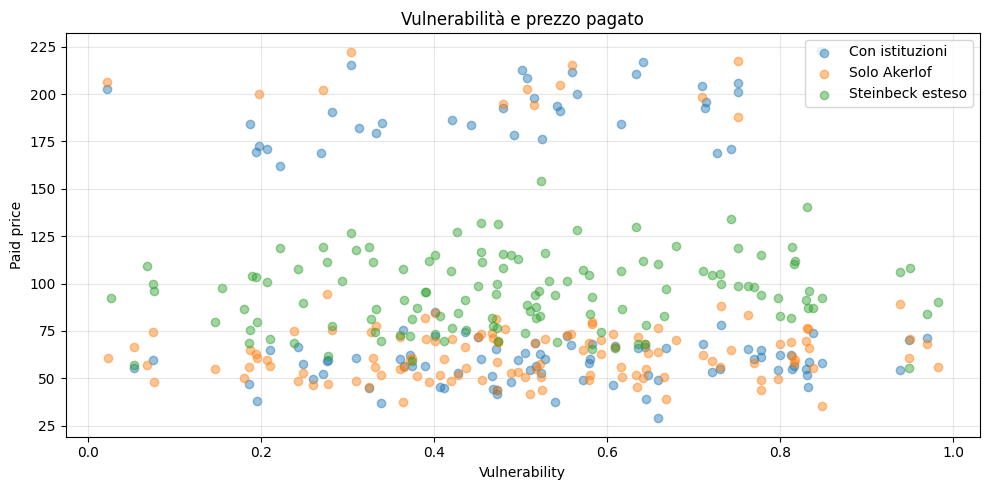

In [8]:



buyers_all.groupby("scenario")[["need", "market_literacy", "vulnerability", "paid_price", "received_quality", "surplus"]].mean().round(3)



fig, ax = plt.subplots()
for scenario, g in buyers_all.groupby("scenario"):
    x = g.loc[g["purchased"], "vulnerability"]
    y = g.loc[g["purchased"], "paid_price"]
    ax.scatter(x, y, alpha=0.45, label=scenario)
ax.set_xlabel("Vulnerability")
ax.set_ylabel("Paid price")
ax.set_title("Vulnerabilità e prezzo pagato")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "vulnerability_paid_price.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "vulnerability_paid_price.png", dpi=300, bbox_inches="tight")
print(f"Salvata figura: {FIGURES_DIR / 'vulnerability_paid_price.pdf'}")
plt.show()


Il grafico sopra aiuta a visualizzare una tesi importante del testo: nel caso Steinbeckiano il prezzo non dipende soltanto dalla qualità attesa, ma può dipendere anche dalla **condizione del compratore**.

## 9. Versione interattiva con slider

Questa sezione è utile quando il notebook viene messo online.  
Se `ipywidgets` è disponibile, compaiono gli slider; altrimenti resta disponibile la funzione `run_scenario(...)`.

In [9]:



def interactive_run(
    info_asymmetry=0.60,
    forced_demand=0.80,
    local_market_power=0.70,
    price_discrimination=0.70,
    institution_strength=0.20,
    inspection_probability=0.20,
    min_quality_standard=0.20,
    share_good_cars=0.35,
    periods=12,
    seed=42
):
    hist, buyers = run_scenario(
        "Scenario interattivo",
        periods=periods,
        seed=seed,
        share_good_cars=share_good_cars,
        info_asymmetry=info_asymmetry,
        forced_demand=forced_demand,
        local_market_power=local_market_power,
        price_discrimination=price_discrimination,
        institution_strength=institution_strength,
        inspection_probability=inspection_probability,
        min_quality_standard=min_quality_standard
    )
    print("Ultimo periodo")
    display(hist.tail(1).round(3))
    print("\nEsiti sui compratori")
    display(summarize_buyers(buyers).round(3))

    for metric in ["trades", "share_lemons", "avg_price", "avg_quality"]:
        plt.figure()
        plt.plot(hist["period"], hist[metric], marker="o")
        plt.title(metric)
        plt.xlabel("Periodo")
        plt.grid(True, alpha=0.3)
        plt.show()

if HAS_WIDGETS:
    widgets.interact(
        interactive_run,
        info_asymmetry=widgets.FloatSlider(value=0.60, min=0.0, max=1.0, step=0.05),
        forced_demand=widgets.FloatSlider(value=0.80, min=0.0, max=1.0, step=0.05),
        local_market_power=widgets.FloatSlider(value=0.70, min=0.0, max=1.0, step=0.05),
        price_discrimination=widgets.FloatSlider(value=0.70, min=0.0, max=1.0, step=0.05),
        institution_strength=widgets.FloatSlider(value=0.20, min=0.0, max=1.0, step=0.05),
        inspection_probability=widgets.FloatSlider(value=0.20, min=0.0, max=1.0, step=0.05),
        min_quality_standard=widgets.FloatSlider(value=0.20, min=0.0, max=0.8, step=0.02),
        share_good_cars=widgets.FloatSlider(value=0.35, min=0.0, max=1.0, step=0.05),
        periods=widgets.IntSlider(value=12, min=4, max=30, step=1),
        seed=widgets.IntSlider(value=42, min=1, max=999, step=1)
    );
else:
    print("ipywidgets non disponibile: usa interactive_run(...) manualmente.")


interactive(children=(FloatSlider(value=0.6, description='info_asymmetry', max=1.0, step=0.05), FloatSlider(va…

## 10. Mini-griglia di esperimenti

Questa cella consente di costruire piccole tabelle comparative pronte per una nota, una presentazione o una discussione seminariale.

In [10]:


grid_rows = []
for forced_demand in [0.2, 0.5, 0.8]:
    for local_market_power in [0.2, 0.5, 0.8]:
        hist, buyers = run_scenario(
            name=f"fd={forced_demand}, lmp={local_market_power}",
            periods=10,
            seed=42,
            share_good_cars=0.35,
            info_asymmetry=0.60,
            forced_demand=forced_demand,
            local_market_power=local_market_power,
            price_discrimination=0.65,
            institution_strength=0.20,
            inspection_probability=0.20,
            min_quality_standard=0.20
        )
        last = hist.tail(1).iloc[0]
        bs = summarize_buyers(buyers).iloc[0]
        grid_rows.append({
            "forced_demand": forced_demand,
            "local_market_power": local_market_power,
            "trades": last["trades"],
            "share_lemons": last["share_lemons"],
            "avg_price": last["avg_price"],
            "avg_quality": last["avg_quality"],
            "purchase_rate": bs["purchase_rate"],
            "avg_surplus_buyers": bs["avg_surplus_buyers"]
        })

grid_df = pd.DataFrame(grid_rows).round(3)
grid_df


,forced_demand,local_market_power,trades,share_lemons,avg_price,avg_quality,purchase_rate,avg_surplus_buyers
0,0.2,0.2,0,0.0,0.0,0.0,0.625,22.539
1,0.2,0.5,0,0.0,0.0,0.0,0.625,15.574
2,0.2,0.8,0,0.0,0.0,0.0,0.625,9.275
3,0.5,0.2,0,0.0,0.0,0.0,0.630,35.105
4,0.5,0.5,0,0.0,0.0,0.0,0.625,28.447
5,0.5,0.8,0,0.0,0.0,0.0,0.625,22.051
6,0.8,0.2,0,0.0,0.0,0.0,0.635,47.228
7,0.8,0.5,0,0.0,0.0,0.0,0.625,42.311
8,0.8,0.8,0,0.0,0.0,0.0,0.625,35.449


## 10bis. Esportazione automatica figure per il paper

Le celle precedenti salvano già in `./figures` i grafici principali del confronto scenari.
La cella seguente costruisce inoltre una figura specifica per il paper: **effetto della forza istituzionale sulla qualità media finale**.

,institution_strength,avg_quality,share_lemons,avg_price,trades,blocked_sales,inspected_cars
0,0.0,0.283,1.000,91.898,128.0,0.0,0.0
1,0.1,0.294,1.000,88.770,108.0,20.0,237.0
2,0.2,0.303,1.000,84.634,101.0,27.0,281.0
3,0.3,0.306,1.000,80.071,95.0,33.0,376.0
4,0.4,0.323,0.968,79.885,93.0,38.0,440.0
5,0.5,0.346,0.915,82.264,94.0,42.0,497.0
6,0.6,0.404,0.808,92.965,99.0,48.0,481.0
7,0.7,0.445,0.726,98.222,106.0,51.0,440.0
8,0.8,0.495,0.630,103.702,119.0,53.0,370.0
9,0.9,0.517,0.590,103.569,122.0,56.0,352.0


Salvata figura: figures/institutions_effect.pdf


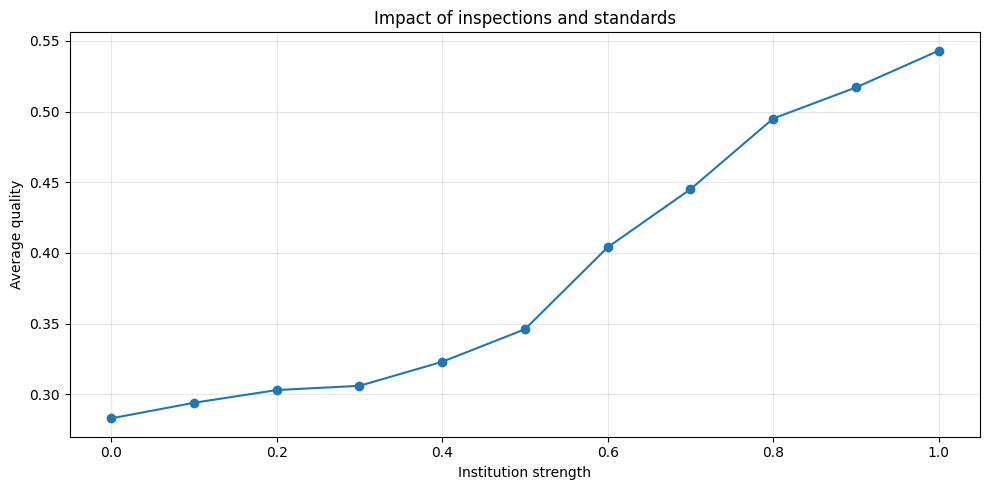

In [11]:

institution_rows = []
for inst_strength in np.linspace(0.0, 1.0, 11):
    hist_inst, buyers_inst = run_scenario(
        name=f"inst={inst_strength:.1f}",
        periods=12,
        seed=42,
        share_good_cars=0.35,
        info_asymmetry=0.60,
        forced_demand=0.85,
        local_market_power=0.70,
        price_discrimination=0.55,
        institution_strength=float(inst_strength),
        inspection_probability=0.85,
        min_quality_standard=0.32
    )
    agg = aggregate_history(hist_inst)
    institution_rows.append({
        "institution_strength": float(inst_strength),
        "avg_quality": float(agg["avg_quality"]),
        "share_lemons": float(agg["share_lemons"]),
        "avg_price": float(agg["avg_price"]),
        "trades": float(agg["total_trades"]),
        "blocked_sales": float(agg["blocked_sales"]),
        "inspected_cars": float(agg["inspected_cars"]),
    })

institution_df = pd.DataFrame(institution_rows).round(3)
display(institution_df)
institution_df.to_csv(TABLES_DIR / "institution_sweep.csv", index=False)

fig, ax = plt.subplots()
ax.plot(institution_df["institution_strength"], institution_df["avg_quality"], marker="o")
ax.set_title("Impact of inspections and standards")
ax.set_xlabel("Institution strength")
ax.set_ylabel("Average quality")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "institutions_effect.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "institutions_effect.png", dpi=300, bbox_inches="tight")
print(f"Salvata figura: {FIGURES_DIR / 'institutions_effect.pdf'}")
plt.show()


## 11. Estensioni possibili

Questo modello può essere ampliato in molti modi:

1. **Reputazione dinamica dei venditori**  
   Le transazioni non sarebbero più puramente one-shot.

2. **Reti sociali dei compratori**  
   L'informazione potrebbe diffondersi per imitazione, racconto, passaparola.

3. **Migrazione / mobilità spaziale**  
   Il potere locale dell'offerta può essere modellato nello spazio.

4. **Credito e indebitamento**  
   Un compratore urgente può comprare anche oltre il budget immediato.

5. **Evoluzione dell'inventario dei venditori**  
   I profitti ottenuti dai lemons possono indurre una specializzazione ulteriore nel commercio di beni scadenti.

6. **Meccanismi istituzionali differenziati**  
   Garanzie, certificazioni, ispettori, intermediari affidabili, cooperative d'acquisto.

## 12. Conclusione

Il punto centrale del notebook è questo:

- il **market for lemons** di Akerlof spiega bene la selezione avversa dovuta ad asimmetria informativa;
- ma il caso evocato nel testo richiede un passo ulteriore, perché la transazione è inserita in una situazione di:
  - urgenza,
  - diseguaglianza cognitiva,
  - vulnerabilità sociale,
  - potere locale dell'offerta,
  - opportunismo strategico.

L'ABM permette di mostrare con chiarezza che il cattivo esito di mercato non nasce da un solo meccanismo, ma dalla **combinazione** di più meccanismi.  
È precisamente questo che rende il caso Steinbeckiano teoricamente interessante.

## 13. Nota pratica per pubblicazione online

Per pubblicare il notebook:

- su **GitHub**: carica il file `.ipynb`;
- su **Binder**: aggiungi un `requirements.txt` con `numpy`, `pandas`, `matplotlib`, `ipywidgets`;
- su **Voilà**: puoi trasformare il notebook in una piccola app interattiva.

Esempio minimale di `requirements.txt`:

```text
numpy
pandas
matplotlib
ipywidgets
voila
```


Le figure del paper vengono salvate automaticamente nella cartella `./figures` quando esegui le celle dei grafici.